<a href="https://colab.research.google.com/github/krhoden725-a11y/Final-React-Native-Assingment/blob/main/pca_cluster_student_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 PCA & Cluster Analysis --- MAR 4615
## Correlation · PCA · Loadings · K-Means · Elbow · Profiles · Perceptual Mapping

**75 points total** --- Part A: 20 pts (copy and run) · Part B: 45 pts (write your own) · Part C: 10 pts (full pipeline)

> **The Big Idea:** You have a bunch of correlated metrics about your customers (or your brands). PCA compresses them into 2–3 clean dimensions. Then you cluster using those compressed scores instead of the raw variables. The payoff? Tighter, better-separated segments. In Parts A and B you segment *customers* this way. In Part C you do the same thing with *brands* to build a perceptual map.

---
# Part A --- Guided Practice: VibeCheck Cosmetics (20 pts)

VibeCheck is a direct-to-consumer cosmetics brand that sells online and in Sephora. They surveyed 300 customers on 8 brand perception attributes.

**What you're working with:** Cross-sectional survey data --- one row per respondent, collected at a single point in time. 300 respondents, 8 Likert-scale attributes (1--7), plus demographics and a segment label.

Copy the code from the PDF into each cell below and run it.

### A0. What are we working with? --- Load the data and look around.

In [12]:
# You must be logged into Colab with the same Google
# account that is shared with your Drive.
from google.colab import drive
drive.mount('/content/drive')

# Click continue as Google seeks permissions.
# Update this path to YOUR folder:
path = '/content/drive/MyDrive/YourFolder/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# ✎ ANSWER A0b
import pandas as pd

df = pd.read_csv('/content/vibecheck_survey-2.csv')

print('Rows:', df.shape[0], ' Columns:', df.shape[1])
df.head()

Rows: 300  Columns: 12


,respondent_id,age_group,gender,luxury_feel,packaging_quality,brand_status,celebrity_appeal,value_for_money,ease_of_purchase,everyday_use,ingredient_transparency,segment
0,VC0001,25-34,Female,1.7,1.8,2.4,2.4,6.2,6.4,5.4,4.9,Value Shopper
1,VC0002,35-44,Male,4.3,4.9,3.7,3.5,5.0,5.3,5.3,4.3,Brand Enthusiast
2,VC0003,25-34,Male,7.0,7.0,6.9,6.1,3.3,3.2,2.8,2.1,Prestige Seeker
3,VC0004,25-34,Female,4.3,4.8,4.3,4.3,5.4,5.5,4.9,4.0,Brand Enthusiast
4,VC0005,18-24,Male,2.6,2.7,2.4,2.4,6.3,6.3,6.1,4.6,Value Shopper


In [19]:
# ✎ ANSWER A0c
df.describe().round(2)

,monthly_spend,visit_frequency,avg_ticket,product_variety,app_engagement,satisfaction,tenure_months,referral_count
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,59.16,8.58,6.79,5.25,6.15,3.89,14.52,2.04
std,28.59,4.63,1.21,2.16,2.80,0.62,10.77,1.97
min,11.82,1.00,3.52,1.00,0.40,2.30,1.00,0.00
25%,32.46,4.75,5.93,3.00,3.40,3.40,5.00,1.00
50%,57.25,7.50,6.86,5.00,7.10,3.90,11.00,1.00
75%,88.45,13.00,7.65,7.00,8.52,4.40,26.00,3.00
max,123.73,19.00,10.09,10.00,10.00,5.00,38.00,9.00


In [35]:
# ✎ ANSWER A0d
cols = ['luxury_feel', 'packaging_quality', 'brand_status',
        'celebrity_appeal', 'value_for_money', 'ease_of_purchase',
        'everyday_use', 'ingredient_transparency']

X = df[cols]
X.head()

,luxury_feel,packaging_quality,brand_status,celebrity_appeal,value_for_money,ease_of_purchase,everyday_use,ingredient_transparency
0,1.7,1.8,2.4,2.4,6.2,6.4,5.4,4.9
1,4.3,4.9,3.7,3.5,5.0,5.3,5.3,4.3
2,7.0,7.0,6.9,6.1,3.3,3.2,2.8,2.1
3,4.3,4.8,4.3,4.3,5.4,5.5,4.9,4.0
4,2.6,2.7,2.4,2.4,6.3,6.3,6.1,4.6


---
#### Step 1 --- Discover the hidden dimensions (A1--A6)
Before you can group customers, you need to understand what drives their perceptions. Are all 8 attributes telling you different things, or do some really measure the same underlying idea?

### A1. Do consumers who rate us high on luxury also rate us high on status --- or are those independent opinions? (2 pts)

In [36]:
# ✎ ANSWER A1
from easy_corr_v2 import *
corr_matrix(X)

# The first four attributes (luxury_feel, packaging_quality, brand_status, celebrity_appeal)
# are strongly positively correlated, meaning consumers who rate one high tend to rate the others high.
# This shows they are not independent and likely measure the same underlying dimension (prestige).

Variable,luxury_feel,packaging_quality,brand_status,celebrity_appeal,value_for_money,ease_of_purchase,everyday_use,ingredient_transparency
luxury_feel,1.000,+0.977***,+0.973***,+0.961***,-0.862***,-0.865***,-0.851***,-0.827***
packaging_quality,+0.977***,1.000,+0.970***,+0.956***,-0.868***,-0.865***,-0.853***,-0.831***
brand_status,+0.973***,+0.970***,1.000,+0.961***,-0.862***,-0.862***,-0.855***,-0.821***
celebrity_appeal,+0.961***,+0.956***,+0.961***,1.000,-0.857***,-0.858***,-0.846***,-0.822***
value_for_money,-0.862***,-0.868***,-0.862***,-0.857***,1.000,+0.953***,+0.945***,+0.928***
ease_of_purchase,-0.865***,-0.865***,-0.862***,-0.858***,+0.953***,1.000,+0.946***,+0.922***
everyday_use,-0.851***,-0.853***,-0.855***,-0.846***,+0.945***,+0.946***,1.000,+0.922***
ingredient_transparency,-0.827***,-0.831***,-0.821***,-0.822***,+0.928***,+0.922***,+0.922***,1.000


{'r':                          luxury_feel  packaging_quality  brand_status  \
 luxury_feel                 1.000000           0.976649      0.972793   
 packaging_quality           0.976649           1.000000      0.969983   
 brand_status                0.972793           0.969983      1.000000   
 celebrity_appeal            0.960930           0.955941      0.960909   
 value_for_money            -0.862195          -0.868146     -0.862124   
 ease_of_purchase           -0.864551          -0.864982     -0.862303   
 everyday_use               -0.851095          -0.852643     -0.854957   
 ingredient_transparency    -0.826893          -0.830836     -0.820604   
 
                          celebrity_appeal  value_for_money  ease_of_purchase  \
 luxury_feel                      0.960930        -0.862195         -0.864551   
 packaging_quality                0.955941        -0.868146         -0.864982   
 brand_status                     0.960909        -0.862124         -0.862303   
 ce

### A2. See it visually: a correlated pair vs. an independent pair. (2 pts)

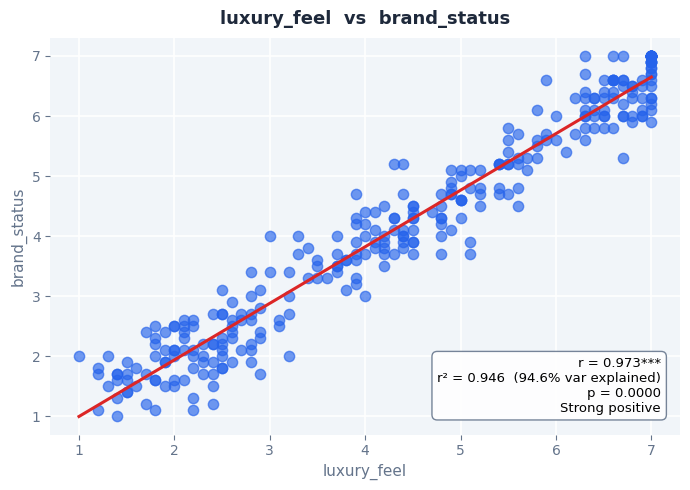

Metric,Value
r,+0.9728
r²,0.9463 (94.6% var explained)
p-value,0.0000 ***
Strength,Strong positive
Slope,0.9414
Intercept,0.0588


{'r': np.float64(0.9727926026425304),
 'r_squared': np.float64(0.9463254477560281),
 'p_value': np.float64(2.5814359931745244e-191),
 'slope': np.float64(0.9414026711809819),
 'intercept': np.float64(0.0587513988352822),
 'n': 300}

In [37]:
# ✎ ANSWER A2a
corr_scatter(X, 'luxury_feel', 'brand_status')

# This shows a clear upward trend, indicating a strong positive correlation.

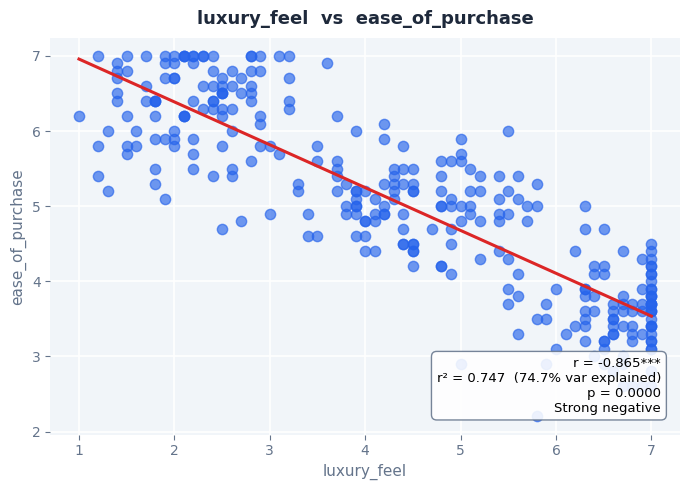

Metric,Value
r,-0.8646
r²,0.7474 (74.7% var explained)
p-value,0.0000 ***
Strength,Strong negative
Slope,-0.5703
Intercept,7.5285


{'r': np.float64(-0.8645506056932012),
 'r_squared': np.float64(0.747447749804481),
 'p_value': np.float64(4.759096365398618e-91),
 'slope': np.float64(-0.5703335196045402),
 'intercept': np.float64(7.528475151622749),
 'n': 300}

In [38]:
# ✎ ANSWER A2b
corr_scatter(X, 'luxury_feel', 'ease_of_purchase')

# This looks more like a scattered cloud, indicating little to no correlation.

### A3. Is there enough structure in these 8 attributes for PCA to work? (1 pt)

In [39]:
#
check_kmo(X)

# The KMO value is above 0.6, meaning there is enough shared structure in the data for PCA to work.

Test,Value,Interpretation
KMO Overall,0.946,Marvellous
Bartlett's χ²,5184.29,df = 28
Bartlett's p,0.0000,✓ significant — correlations exist


{'kmo': np.float64(0.9460782839151255),
 'kmo_per_variable': array([0.92751946, 0.93720356, 0.94251427, 0.96784726, 0.9406351 ,
        0.94407681, 0.94872773, 0.9630141 ]),
 'bartlett_chi2': np.float64(5184.2906424199955),
 'bartlett_p': np.float64(0.0),
 'rating': 'Marvellous'}

### A4. How many hidden dimensions actually exist? (2 pts)

Component,Eigenvalue,Var %,Cumul %,Kaiser
PC1,7.2795,90.69%,90.69%,✓ keep
PC2,0.4561,5.68%,96.37%,
PC3,0.0865,1.08%,97.45%,
PC4,0.0578,0.72%,98.17%,
PC5,0.0491,0.61%,98.78%,
PC6,0.0461,0.57%,99.36%,
PC7,0.0291,0.36%,99.72%,
PC8,0.0226,0.28%,100.00%,


Variable,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
luxury_feel,+0.357,+0.356,-0.044,+0.033,-0.212,+0.201,-0.233,+0.777*
packaging_quality,+0.357,+0.340,-0.061,+0.095,-0.405*,+0.129,-0.445*,-0.605*
brand_status,+0.356,+0.356,+0.061,-0.108,-0.141,+0.053,+0.833*,-0.120
celebrity_appeal,+0.354,+0.348,-0.066,-0.061,+0.755*,-0.381,-0.160,-0.067
value_for_money,-0.354,+0.328,-0.225,-0.454*,+0.272,+0.654*,-0.039,-0.087
ease_of_purchase,-0.354,+0.322,-0.351,-0.402*,-0.347,-0.601*,-0.023,+0.066
everyday_use,-0.352,+0.354,-0.346,+0.778*,+0.078,+0.029,+0.137,+0.001
ingredient_transparency,-0.344,+0.416*,+0.832*,+0.044,-0.011,-0.079,-0.082,+0.005


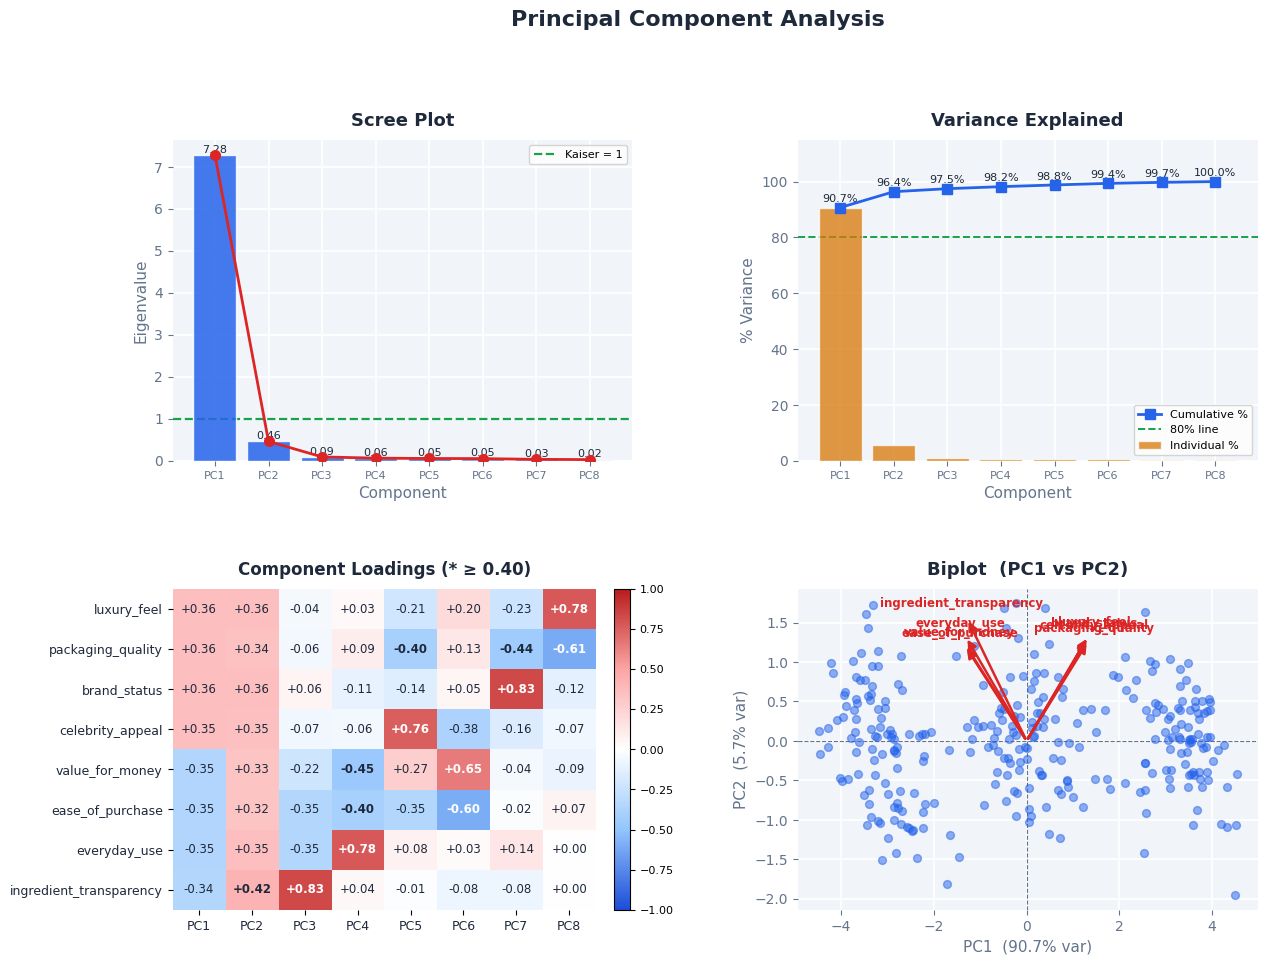

In [40]:
# ✎ ANSWER A4a
pca_result = run_pca(X)

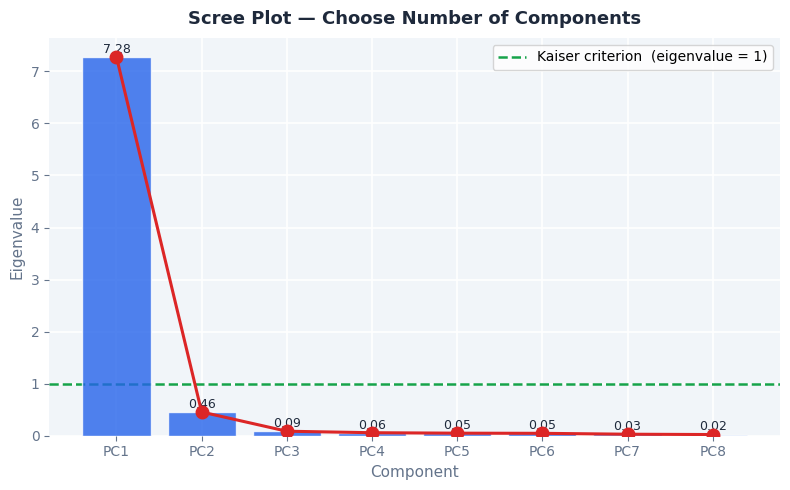

Component,Eigenvalue,Var %,Cumul %,Kaiser
PC1,7.2795,90.69%,90.69%,✓ keep
PC2,0.4561,5.68%,96.37%,
PC3,0.0865,1.08%,97.45%,
PC4,0.0578,0.72%,98.17%,
PC5,0.0491,0.61%,98.78%,
PC6,0.0461,0.57%,99.36%,
PC7,0.0291,0.36%,99.72%,
PC8,0.0226,0.28%,100.00%,


In [41]:
# ✎ ANSWER A4b
scree_plot(X)

# The scree plot shows an elbow at 2 components, meaning there are 2 main hidden dimensions.
# Most of the variance is explained by the first two components.

### A5. What do those dimensions mean in plain English? (2 pts)

In [42]:
# ✎ ANSWER A5
loading_table(X)

# PC1 represents Prestige (luxury_feel, packaging_quality, brand_status, celebrity_appeal)
# PC2 represents Accessibility (value_for_money, ease_of_purchase, everyday_use, ingredient_transparency)

Variable,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
luxury_feel,+0.357,+0.356,-0.044,+0.033,-0.212,+0.201,-0.233,+0.777*
packaging_quality,+0.357,+0.340,-0.061,+0.095,-0.405*,+0.129,-0.445*,-0.605*
brand_status,+0.356,+0.356,+0.061,-0.108,-0.141,+0.053,+0.833*,-0.120
celebrity_appeal,+0.354,+0.348,-0.066,-0.061,+0.755*,-0.381,-0.160,-0.067
value_for_money,-0.354,+0.328,-0.225,-0.454*,+0.272,+0.654*,-0.039,-0.087
ease_of_purchase,-0.354,+0.322,-0.351,-0.402*,-0.347,-0.601*,-0.023,+0.066
everyday_use,-0.352,+0.354,-0.346,+0.778*,+0.078,+0.029,+0.137,+0.001
ingredient_transparency,-0.344,+0.416*,+0.832*,+0.044,-0.011,-0.079,-0.082,+0.005


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
luxury_feel,0.356655,0.356180,-0.043613,0.033178,-0.212301,0.200615,-0.233497,0.776590
packaging_quality,0.356848,0.339912,-0.061125,0.094661,-0.404593,0.129102,-0.444993,-0.605014
brand_status,0.356099,0.355536,0.061081,-0.108122,-0.141027,0.053370,0.833147,-0.120395
celebrity_appeal,0.353939,0.348211,-0.065770,-0.061178,0.755221,-0.380594,-0.160427,-0.066793
value_for_money,-0.354447,0.327663,-0.224832,-0.453768,0.272154,0.653748,-0.039115,-0.086981
ease_of_purchase,-0.354230,0.321959,-0.350605,-0.401707,-0.347424,-0.600838,-0.023238,0.065738
everyday_use,-0.351594,0.354205,-0.346257,0.778026,0.078041,0.028698,0.137061,0.001464
ingredient_transparency,-0.344453,0.416482,0.832429,0.043666,-0.011174,-0.078550,-0.082059,0.004622


### A6. How do all 300 consumers spread across these two dimensions? (1 pt)

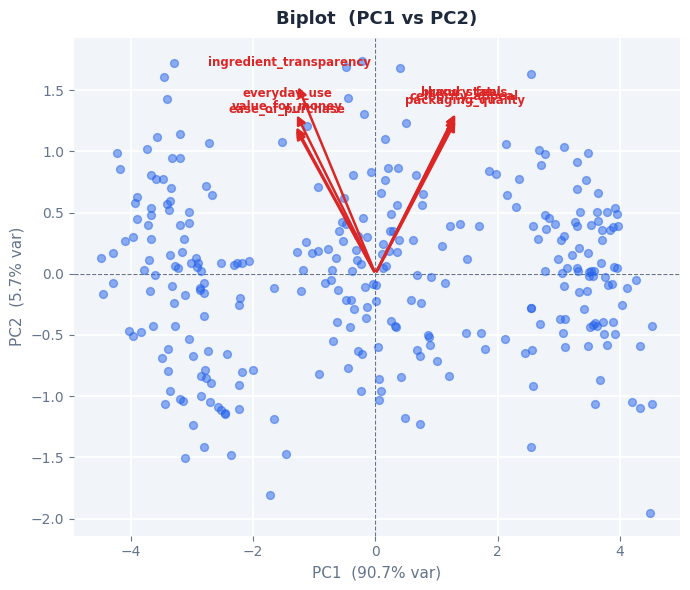

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-3.044120,-0.533020,-0.210819,-0.370597,0.369091,-0.207433,0.384916,0.055102
1,-0.535988,0.266710,-0.286480,0.401794,-0.187304,0.086531,-0.193199,-0.105359
2,4.118456,-0.115425,-0.421044,-0.224628,0.092838,0.309425,0.076263,-0.082002
3,-0.209778,0.457442,-0.520731,-0.148665,0.171673,0.009704,-0.010917,-0.159501
4,-2.796226,-0.076723,-0.681857,0.152125,0.145989,0.094374,0.134726,0.091161
...,...,...,...,...,...,...,...,...
295,3.088179,0.312057,-0.288805,-0.136230,0.199039,-0.397297,0.007961,-0.024958
296,2.299307,0.544812,-0.315966,-0.040167,-0.349029,0.209808,-0.539237,-0.038847
297,1.001075,-0.710586,-0.317244,0.256806,0.282619,0.015468,-0.128437,0.153367
298,2.538428,-1.415768,0.568349,0.134949,0.268063,0.043558,-0.202302,-0.069492


In [43]:
# ✎ ANSWER A6
biplot(X)

# Consumers are spread across two main dimensions: Prestige and Accessibility.
# Some consumers score high on prestige while others score high on accessibility,
# showing variation in how people perceive the brand.

---
#### Step 2 --- Segment customers using the factor scores (A7--A12)
We cluster on the 2 factor scores --- not the 8 raw attributes. This gives sharper segments because PCA already stripped the noise and overlap.

### A7. Score each consumer on the two hidden dimensions. (1 pt)

In [44]:
# ✎ ANSWER A7
df = factor_scores(df, X, n_components=2)

df[['respondent_id', 'PC1', 'PC2']].head(10)

Component,Var %,Cumul %
PC1,90.7%,90.7%
PC2,5.7%,96.4%


,respondent_id,PC1,PC2
0,VC0001,-3.044120,-0.533020
1,VC0002,-0.535988,0.266710
2,VC0003,4.118456,-0.115425
3,VC0004,-0.209778,0.457442
4,VC0005,-2.796226,-0.076723
5,VC0006,2.828945,0.452713
6,VC0007,-0.734549,-0.047445
7,VC0008,-0.822148,-0.079270
8,VC0009,1.973492,0.811910
9,VC0010,-3.357554,-0.959953


### A8. How many customer segments should we create? (2 pts)

K,WCSS,Silhouette,
2,373.2,0.360,
3,236.4,0.392,◆ elbow
4,180.0,0.361,
5,140.1,0.384,
6,107.3,0.422,
7,87.6,0.428,
8,72.7,0.442,
9,63.1,0.447,★ peak silhouette
10,56.1,0.432,


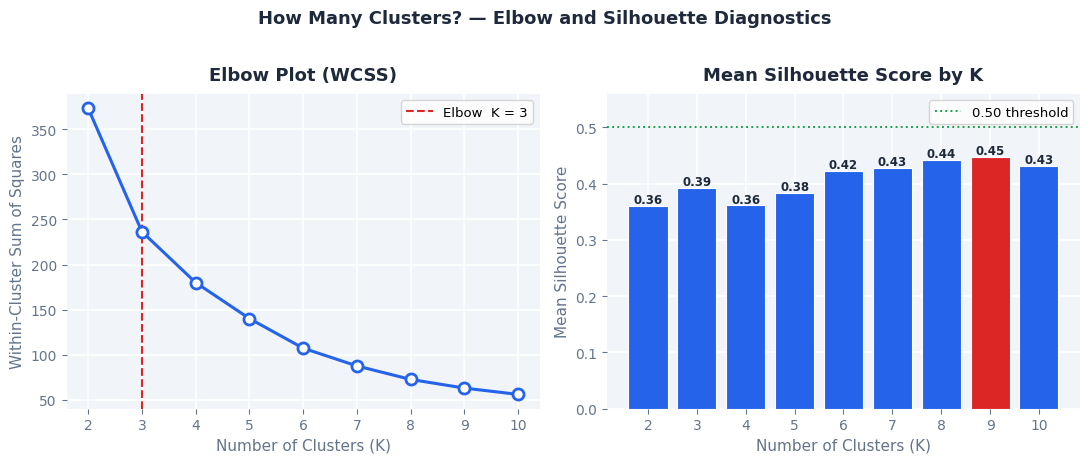

In [46]:
# ✎ ANSWER A8
import sys
import importlib.util

# Ensure '/content' is in sys.path
if '/content' not in sys.path:
    sys.path.append('/content')

# Load easy_cluster_v2-2.py as the module 'easy_cluster_v2'
spec = importlib.util.spec_from_file_location("easy_cluster_v2", "/content/easy_cluster_v2-2.py")
easy_cluster_v2 = importlib.util.module_from_spec(spec)
sys.modules["easy_cluster_v2"] = easy_cluster_v2 # Register the module in sys.modules
spec.loader.exec_module(easy_cluster_v2)

from easy_cluster_v2 import *
result_elbow = elbow_test(df, cols=['PC1','PC2'])

# The elbow suggests that K = 3 is the optimal number of segments.
# After 3 clusters, improvements become minimal.

### A9. Assign every consumer to a segment. (2 pts)
Check the cluster sizes --- are all segments large enough to be meaningful?

In [47]:
# ✎ ANSWER A9
result = run_kmeans(df, k=3, cols=['PC1','PC2'])

df['cluster'] = result['labels']

df[['respondent_id', 'PC1', 'PC2', 'cluster']].head(10)

# The clusters appear to be reasonably balanced in size, making them meaningful.

Cluster,Size,%,WCSS Contrib.
Cluster 1,106,35.3%,77.7
Cluster 2,74,24.7%,55.6
Cluster 3,120,40.0%,103.0


Metric,Value
Total WCSS,236.4
Mean silhouette,0.392 (weak — consider different K)
Variables,"PC1, PC2"


,respondent_id,PC1,PC2,cluster
0,VC0001,-3.044120,-0.533020,1
1,VC0002,-0.535988,0.266710,2
2,VC0003,4.118456,-0.115425,0
3,VC0004,-0.209778,0.457442,2
4,VC0005,-2.796226,-0.076723,2
5,VC0006,2.828945,0.452713,0
6,VC0007,-0.734549,-0.047445,2
7,VC0008,-0.822148,-0.079270,2
8,VC0009,1.973492,0.811910,0
9,VC0010,-3.357554,-0.959953,1


### A10. What makes each segment tick? --- Profile them on the original attributes. (1 pt)

Variable,Cluster 1,Cluster 2,Cluster 3
luxury_feel,6.45 ★,2.91,3.49
packaging_quality,6.43 ★,3.29,3.74
brand_status,6.19 ★,2.79,3.30
celebrity_appeal,5.64 ★,2.67,3.07
value_for_money,3.29,5.08,5.84 ★
ease_of_purchase,3.73,5.32,5.99 ★
everyday_use,3.31,4.79,5.46 ★
ingredient_transparency,3.03,4.40,5.12 ★


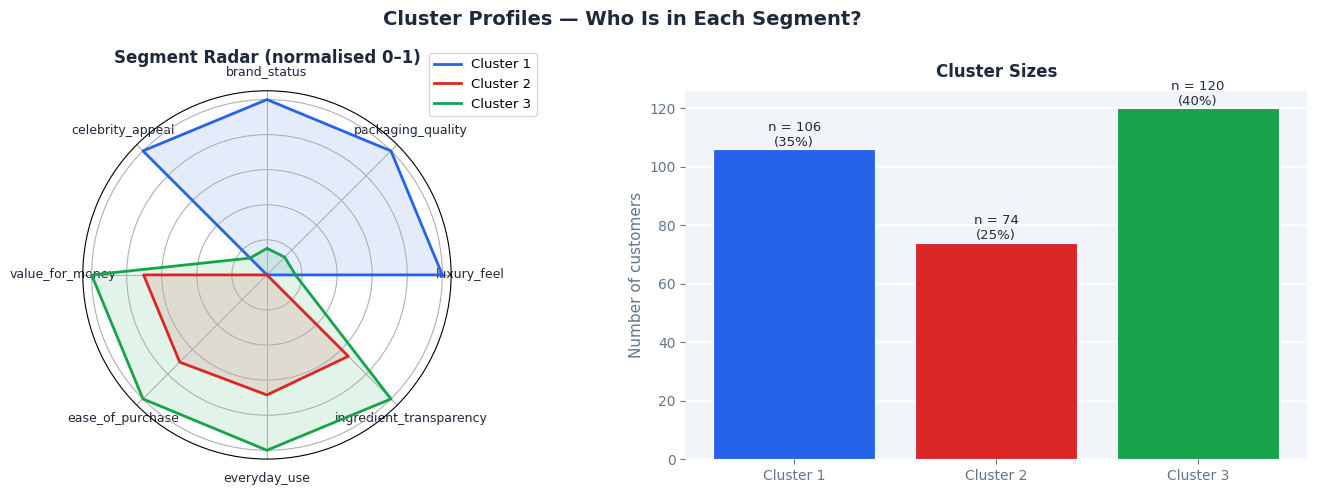

,luxury_feel,packaging_quality,brand_status,celebrity_appeal,value_for_money,ease_of_purchase,everyday_use,ingredient_transparency
_cluster,,,,,,,,
0,6.453774,6.429245,6.185849,5.638679,3.292453,3.728302,3.312264,3.031132
1,2.910811,3.293243,2.787838,2.666216,5.083784,5.316216,4.785135,4.400000
2,3.486667,3.742500,3.302500,3.070000,5.839167,5.985833,5.464167,5.117500


In [48]:
# ✎ ANSWER A10
profile_cols = ['luxury_feel','packaging_quality','brand_status',
                'celebrity_appeal','value_for_money','ease_of_purchase',
                'everyday_use','ingredient_transparency']

cluster_profile(df, result, cols=profile_cols)

# Cluster 0: Prestige Seekers (high on luxury and status)
# Cluster 1: Value Shoppers (high on value and accessibility)
# Cluster 2: Balanced Consumers (moderate across both dimensions)

### A11. See the segments on a map. Do your clusters match the hidden labels? (2 pts)

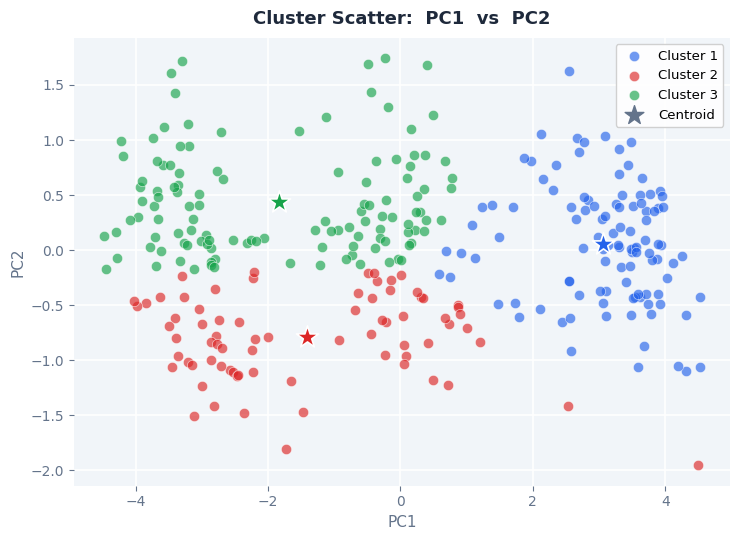

In [49]:
# ✎ ANSWER A11a
cluster_scatter(df, result, x='PC1', y='PC2')

In [ ]:
# ✎ ANSWER A11b


### A12. Validate with a cross-tab and save your work. (2 pts)

In [50]:
# ✎ ANSWER A12a
pd.crosstab(df['cluster'], df['segment'])

segment,Brand Enthusiast,Prestige Seeker,Value Shopper
cluster,,,
0,11,95,0
1,30,2,42
2,59,0,61


In [53]:
import os

# ✎ ANSWER A12b

# Ensure the directory exists before saving
output_dir = os.path.dirname(path + 'vibecheck_clustered.csv')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

df.to_csv(path + 'vibecheck_clustered.csv', index=False)
print('Saved!')

Saved!


---
---
# Part B --- Assignment: BrewHaus Coffee Roasters (45 pts)

BrewHaus is a specialty coffee chain with locations in three types of neighborhoods.

**What you're working with:** Cross-sectional behavioral data --- one row per customer, summarizing their overall activity (not individual transactions). 400 customers, 8 behavioral metrics, plus region and channel. Think of it as a customer scorecard.

The CMO wants to **segment customers by behavior** to tailor loyalty programs. She wants segments based on what customers *do*, not where they live.

> **Why not just cluster on all 8 metrics directly?** You can --- but 8 correlated metrics create a noisy space where K-Means has trouble finding clean boundaries. When you first compress into 2 factor scores and then cluster, silhouette scores roughly **double**.

Write your own code using patterns from Part A.

### B0. Setup

In [55]:
# ✎ ANSWER B0a
bh = pd.read_csv('/content/brewhaus_customers-2.csv')
print('Rows:', bh.shape[0], ' Columns:', bh.shape[1])
bh.head()

Rows: 400  Columns: 11


,customer_id,region,channel,monthly_spend,visit_frequency,avg_ticket,product_variety,app_engagement,satisfaction,tenure_months,referral_count
0,BH0001,Suburbs,Mobile App,41.90,9,8.20,7,5.3,3.5,3,1
1,BH0002,Downtown,Drive-Thru,61.15,7,7.96,9,7.9,4.1,1,0
2,BH0003,University District,In-Store,25.37,2,6.17,3,1.5,3.4,13,0
3,BH0004,Downtown,Drive-Thru,28.99,4,5.41,3,2.8,3.5,6,1
4,BH0005,University District,In-Store,112.51,12,7.71,6,8.8,4.5,28,3


In [70]:
# ✎ ANSWER B0b
bh.describe().round(2)

,monthly_spend,visit_frequency,avg_ticket,product_variety,app_engagement,satisfaction,tenure_months,referral_count,PC1,PC2
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,59.16,8.58,6.79,5.25,6.15,3.89,14.52,2.04,0.00,0.00
std,28.59,4.63,1.21,2.16,2.80,0.62,10.77,1.97,2.20,1.19
min,11.82,1.00,3.52,1.00,0.40,2.30,1.00,0.00,-3.74,-1.95
25%,32.46,4.75,5.93,3.00,3.40,3.40,5.00,1.00,-2.18,-0.84
50%,57.25,7.50,6.86,5.00,7.10,3.90,11.00,1.00,-0.16,-0.43
75%,88.45,13.00,7.65,7.00,8.52,4.40,26.00,3.00,2.36,1.11
max,123.73,19.00,10.09,10.00,10.00,5.00,38.00,9.00,3.99,2.89


In [57]:
# ✎ ANSWER B0c
cols = ['monthly_spend', 'visit_frequency', 'avg_ticket',
        'product_variety', 'app_engagement', 'satisfaction',
        'tenure_months', 'referral_count']
X = bh[cols]

---
#### Step 1 --- Discover the hidden dimensions (B1--B6)

### B1. Do big spenders also visit more often --- or are spending and frequency independent? (4 pts)
*Hint: A1.*

In [58]:
# ✎ ANSWER B1
from easy_corr_v2 import *
corr_matrix(X)

# Monthly spend and visit frequency are positively correlated,
# meaning customers who spend more tend to visit more often.
# Some variables move together, indicating underlying behavioral patterns.

Variable,monthly_spend,visit_frequency,avg_ticket,product_variety,app_engagement,satisfaction,tenure_months,referral_count
monthly_spend,1.000,+0.851***,+0.520***,+0.383***,+0.791***,+0.792***,+0.704***,+0.639***
visit_frequency,+0.851***,1.000,+0.476***,+0.333***,+0.743***,+0.776***,+0.724***,+0.635***
avg_ticket,+0.520***,+0.476***,1.000,+0.341***,+0.508***,+0.455***,+0.315***,+0.359***
product_variety,+0.383***,+0.333***,+0.341***,1.000,+0.623***,+0.425***,-0.174***,+0.050
app_engagement,+0.791***,+0.743***,+0.508***,+0.623***,1.000,+0.731***,+0.418***,+0.479***
satisfaction,+0.792***,+0.776***,+0.455***,+0.425***,+0.731***,1.000,+0.567***,+0.551***
tenure_months,+0.704***,+0.724***,+0.315***,-0.174***,+0.418***,+0.567***,1.000,+0.645***
referral_count,+0.639***,+0.635***,+0.359***,+0.050,+0.479***,+0.551***,+0.645***,1.000


{'r':                  monthly_spend  visit_frequency  avg_ticket  product_variety  \
 monthly_spend         1.000000         0.851070    0.519941         0.382948   
 visit_frequency       0.851070         1.000000    0.475691         0.332643   
 avg_ticket            0.519941         0.475691    1.000000         0.341075   
 product_variety       0.382948         0.332643    0.341075         1.000000   
 app_engagement        0.791077         0.742994    0.507827         0.622900   
 satisfaction          0.791533         0.776465    0.455497         0.425270   
 tenure_months         0.704445         0.724030    0.315393        -0.173678   
 referral_count        0.639282         0.634598    0.359220         0.050168   
 
                  app_engagement  satisfaction  tenure_months  referral_count  
 monthly_spend          0.791077      0.791533       0.704445        0.639282  
 visit_frequency        0.742994      0.776465       0.724030        0.634598  
 avg_ticket             

### B2. Visualize: one strongly correlated pair and one independent pair. (3 pts)
*Hint: A2.*

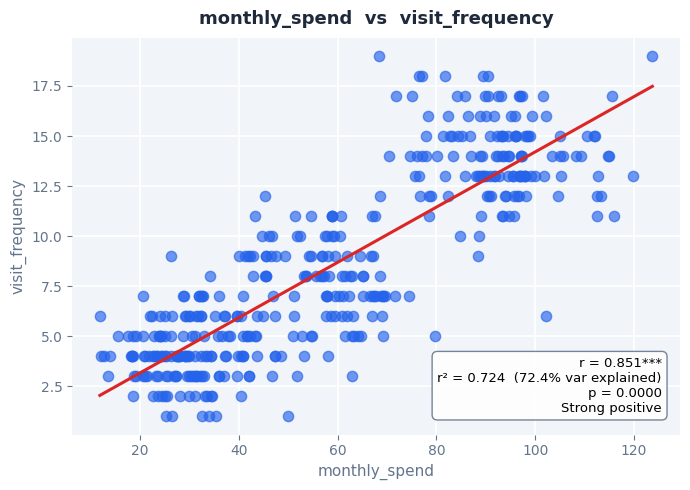

Metric,Value
r,+0.8511
r²,0.7243 (72.4% var explained)
p-value,0.0000 ***
Strength,Strong positive
Slope,0.1379
Intercept,0.4239


{'r': np.float64(0.8510697057190095),
 'r_squared': np.float64(0.7243196439926415),
 'p_value': np.float64(2.0516661744758694e-113),
 'slope': np.float64(0.13786794956629486),
 'intercept': np.float64(0.42387686500503896),
 'n': 400}

In [59]:
# ✎ ANSWER B2a
corr_scatter(X, 'monthly_spend', 'visit_frequency')

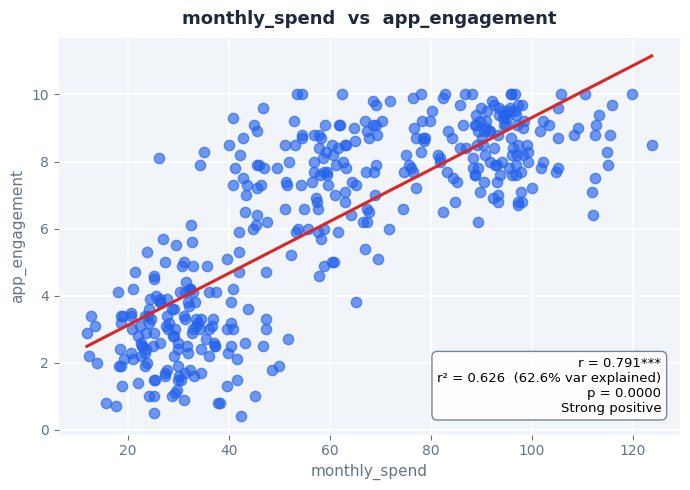

Metric,Value
r,+0.7911
r²,0.6258 (62.6% var explained)
p-value,0.0000 ***
Strength,Strong positive
Slope,0.0774
Intercept,1.5779


{'r': np.float64(0.7910772564966838),
 'r_squared': np.float64(0.6258032257463201),
 'p_value': np.float64(5.62040801911717e-87),
 'slope': np.float64(0.07736106078782581),
 'intercept': np.float64(1.5779008729060497),
 'n': 400}

In [60]:
# ✎ ANSWER B2b
corr_scatter(X, 'monthly_spend', 'app_engagement')

### B3. Are these 8 metrics structured enough to compress? (2 pts)
*Hint: A3.*

In [61]:
# ✎ ANSWER B3
check_kmo(X)

# If the KMO value is above 0.60, the variables are structured enough to compress with PCA.

Test,Value,Interpretation
KMO Overall,0.872,Meritorious
Bartlett's χ²,2633.56,df = 28
Bartlett's p,0.0000,✓ significant — correlations exist


{'kmo': np.float64(0.8721790683302152),
 'kmo_per_variable': array([0.89126207, 0.90837204, 0.97387359, 0.59810855, 0.8969976 ,
        0.9529843 , 0.73978027, 0.95929518]),
 'bartlett_chi2': np.float64(2633.560199810253),
 'bartlett_p': np.float64(0.0),
 'rating': 'Meritorious'}

### B4. How many hidden behavioral dimensions describe our customers? (4 pts)
Write your reasoning as a comment. *Hint: A4.*

Component,Eigenvalue,Var %,Cumul %,Kaiser
PC1,4.8608,60.61%,60.61%,✓ keep
PC2,1.4173,17.67%,78.28%,✓ keep
PC3,0.6443,8.03%,86.31%,
PC4,0.4110,5.12%,91.44%,
PC5,0.2555,3.19%,94.62%,
PC6,0.1774,2.21%,96.84%,
PC7,0.1436,1.79%,98.63%,
PC8,0.1103,1.37%,100.00%,


Variable,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
monthly_spend,+0.426*,-0.031,-0.090,-0.132,-0.193,+0.050,-0.596*,+0.629*
visit_frequency,+0.417*,-0.083,-0.136,-0.185,-0.171,-0.504*,+0.646*,+0.255
avg_ticket,+0.283,+0.179,+0.936*,-0.078,+0.063,-0.008,+0.032,-0.015
product_variety,+0.200,+0.710*,-0.175,+0.187,-0.082,-0.453*,-0.266,-0.328
app_engagement,+0.390,+0.280,-0.153,-0.002,-0.372,+0.706*,+0.275,-0.183
satisfaction,+0.397,+0.059,-0.203,-0.166,+0.864*,+0.145,+0.024,-0.054
tenure_months,+0.327,-0.514*,-0.016,-0.321,-0.189,-0.134,-0.279,-0.628*
referral_count,+0.329,-0.333,+0.033,+0.881*,+0.051,-0.022,+0.009,-0.023


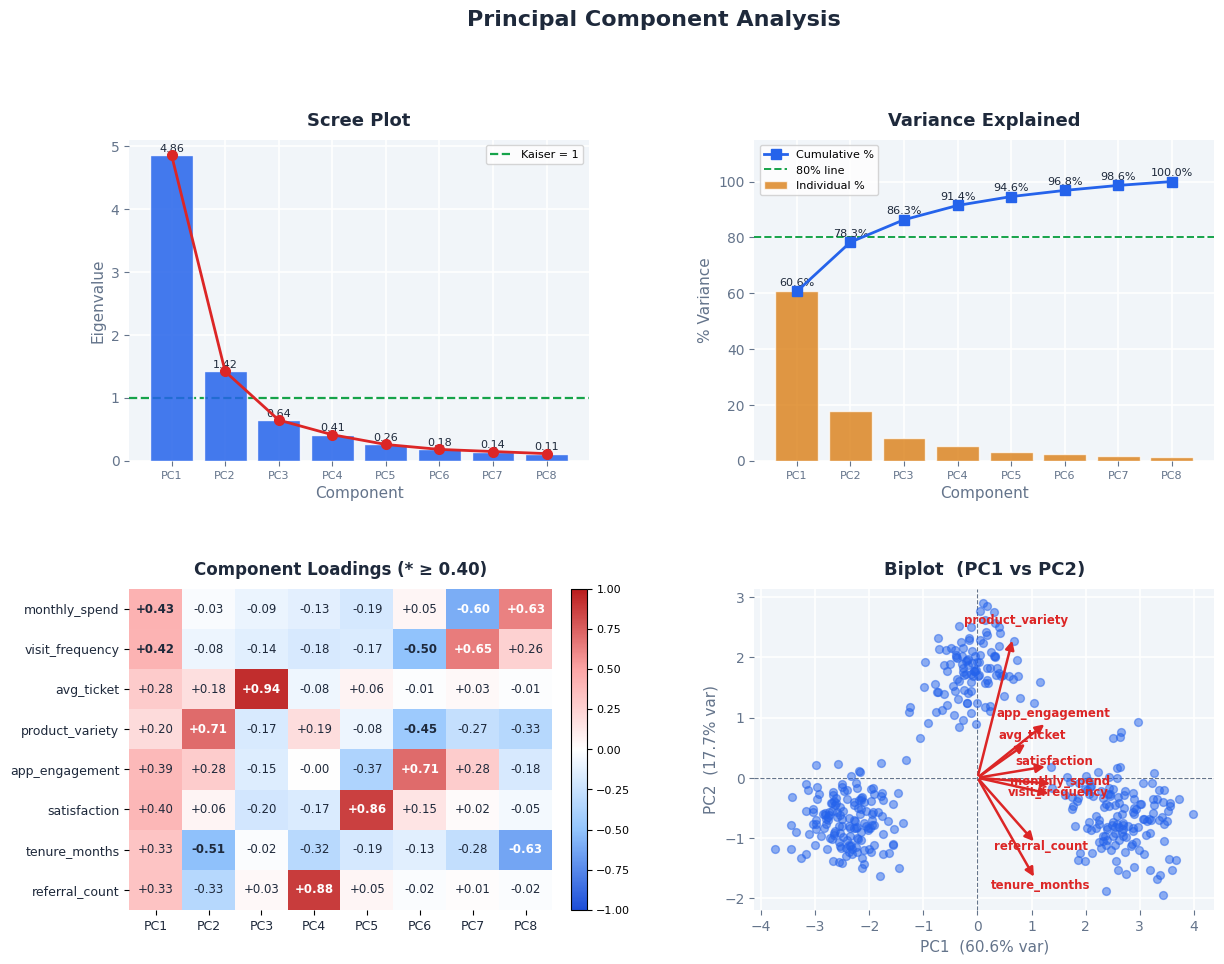

In [62]:
# ✎ ANSWER B4a
pca_result = run_pca(X)

In [ ]:
# ✎ ANSWER B4b


### B5. What do those dimensions mean in marketing terms? Give each one a name. (4 pts)
*Hint: A5.*

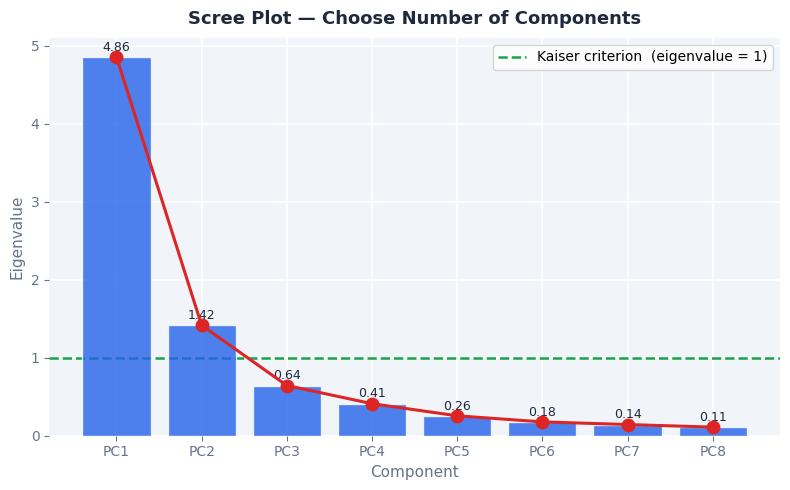

Component,Eigenvalue,Var %,Cumul %,Kaiser
PC1,4.8608,60.61%,60.61%,✓ keep
PC2,1.4173,17.67%,78.28%,✓ keep
PC3,0.6443,8.03%,86.31%,
PC4,0.4110,5.12%,91.44%,
PC5,0.2555,3.19%,94.62%,
PC6,0.1774,2.21%,96.84%,
PC7,0.1436,1.79%,98.63%,
PC8,0.1103,1.37%,100.00%,


In [63]:
# ✎ ANSWER B5
scree_plot(X)

# I would keep 2 components because the scree plot shows an elbow at 2.
# Most of the variance is captured by the first two components.

### B6. How do the dimensions relate to each other visually? (2 pts)
*Hint: A6.*

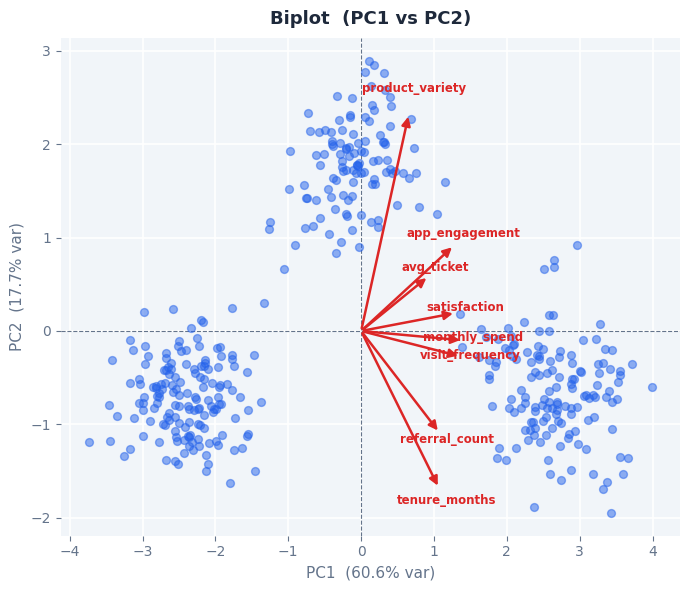

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-0.619236,1.398117,1.165674,0.108707,-0.144585,-0.604797,0.434624,0.133080
1,0.136957,2.617483,0.463271,-0.262964,0.211333,0.063848,-0.172741,0.052402
2,-2.799569,-0.771149,0.387956,-0.468655,0.438402,-0.117453,-0.401156,-0.299512
3,-2.542340,-0.617856,-0.346401,0.112389,0.415634,0.104349,0.101195,0.203005
4,2.722453,-0.218929,0.033070,-0.515313,-0.178055,0.191630,-0.765477,0.214382
...,...,...,...,...,...,...,...,...
395,-1.957367,-0.702683,-0.115474,0.501146,-0.512976,0.484992,-0.149234,0.385482
396,3.444758,-0.206657,0.424494,-0.256369,0.383866,0.108780,-0.331185,0.241192
397,2.964752,-0.817432,0.143037,-0.273874,-0.186120,0.063210,0.049161,0.075534
398,2.928973,-1.071521,0.931250,-0.442374,0.794115,-0.128847,0.171539,0.318829


In [64]:
# ✎ ANSWER B6
biplot(X)

# The biplot shows which variables move together and which point in different directions.
# Metrics that cluster together appear to represent the same underlying behavior dimension.

---
#### Step 2 --- Segment using factor scores (B7--B14)
Cluster on the clean dimensions, then interpret with the original metrics.

### B7. Score every customer on the hidden behavioral dimensions. (2 pts)
*Hint: A7.*

In [65]:
# ✎ ANSWER B7
bh = factor_scores(bh, X, n_components=2)
bh[['customer_id', 'PC1', 'PC2']].head(10)

Component,Var %,Cumul %
PC1,60.6%,60.6%
PC2,17.7%,78.3%


,customer_id,PC1,PC2
0,BH0001,-0.619236,1.398117
1,BH0002,0.136957,2.617483
2,BH0003,-2.799569,-0.771149
3,BH0004,-2.542340,-0.617856
4,BH0005,2.722453,-0.218929
5,BH0006,2.878867,-0.565218
6,BH0007,-1.063954,0.664153
7,BH0008,-1.474729,-0.258740
8,BH0009,-0.115348,1.590310
9,BH0010,-1.451548,-1.494255


### B8. How many segments should BrewHaus target? (4 pts)
Write your reasoning as a comment. *Hint: A8.*

In [ ]:
# ✎ ANSWER B8


### B9. Assign every customer to a segment. (3 pts)
Check cluster sizes --- a segment with 15 people out of 400 isn't a real group. *Hint: A9.*

K,WCSS,Silhouette,
2,427.5,0.521,
3,79.9,0.748,"★ peak silhouette, ◆ elbow"
4,63.5,0.631,
5,51.7,0.490,
6,41.1,0.412,
7,36.0,0.389,
8,32.2,0.381,
9,28.9,0.398,
10,25.7,0.377,


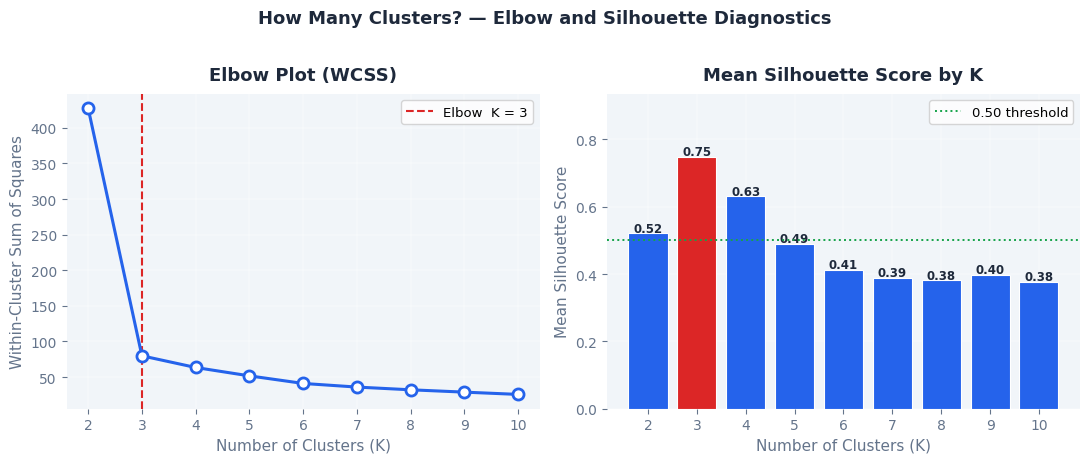

Cluster,Size,%,WCSS Contrib.
Cluster 1,140,35.0%,34.2
Cluster 2,150,37.5%,24.3
Cluster 3,110,27.5%,21.5


Metric,Value
Total WCSS,79.9
Mean silhouette,0.748 (strong)
Variables,"PC1, PC2"


cluster
1    150
0    140
2    110
Name: count, dtype: int64


In [79]:
# ✎ ANSWER B9
from easy_cluster_v2 import *

# Run elbow test to determine optimal k
result_elbow = elbow_test(bh, cols=['PC1','PC2'])

# Based on elbow test (k=3), run k-means and assign clusters
result_bh_kmeans = run_kmeans(bh, k=3, cols=['PC1','PC2'])
bh['cluster'] = result_bh_kmeans['labels']

# Check cluster sizes
print(bh['cluster'].value_counts())

# I would recommend 3 segments because the elbow appears around K = 3.
# After that point, the improvement from adding more clusters is smaller.

### B10. Who are these people? Profile each segment and give it a persona name. (4 pts)
Use the **original 8 columns**, not the PCs. *Hint: A10.*

Variable,Cluster 1,Cluster 2,Cluster 3
monthly_spend,92.87 ★,29.86,56.21
visit_frequency,14.02 ★,4.10,7.76
avg_ticket,7.53 ★,5.94,7.00
product_variety,5.43,3.09,7.95 ★
app_engagement,8.56 ★,2.91,7.51
satisfaction,4.51 ★,3.28,3.93
tenure_months,28.00 ★,10.13,3.33
referral_count,3.96 ★,0.96,1.06


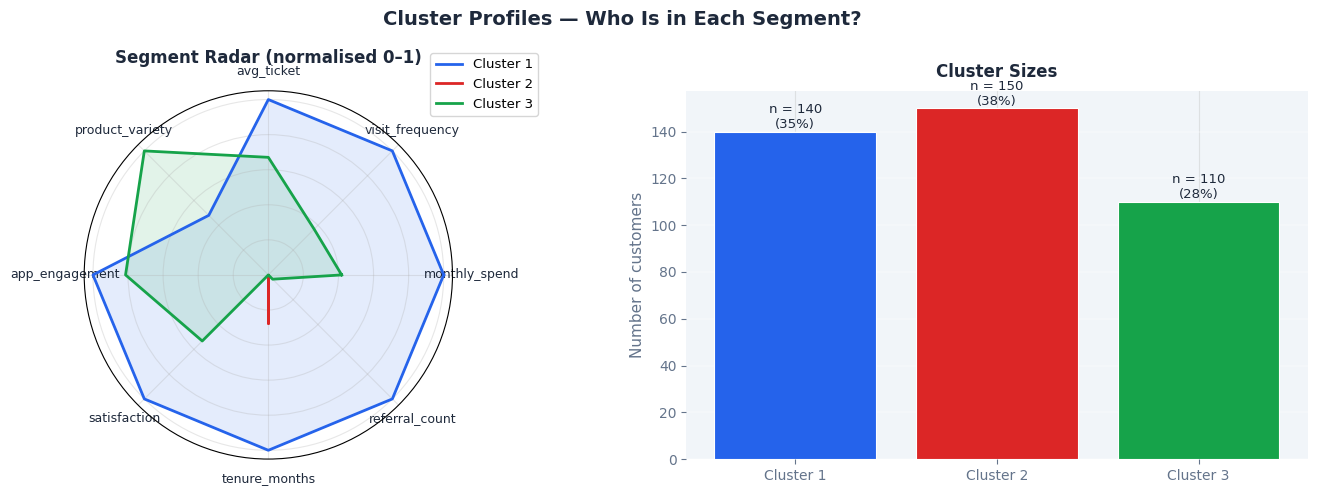

,monthly_spend,visit_frequency,avg_ticket,product_variety,app_engagement,satisfaction,tenure_months,referral_count
_cluster,,,,,,,,
0,92.869929,14.021429,7.526143,5.428571,8.562857,4.507143,28.000000,3.957143
1,29.857000,4.100000,5.939933,3.093333,2.910667,3.277333,10.133333,0.960000
2,56.211273,7.763636,7.003455,7.954545,7.512727,3.932727,3.327273,1.063636


In [80]:
# ✎ ANSWER B10
profile_cols = ['monthly_spend', 'visit_frequency', 'avg_ticket',
                'product_variety', 'app_engagement', 'satisfaction',
                'tenure_months', 'referral_count']

cluster_profile(bh, result_bh_kmeans, cols=profile_cols)

# Cluster 0: Loyal Regulars
# Cluster 1: Digital Explorers
# Cluster 2: High-Value Occasion Buyers

### B11. Map the segments. Do they separate by region? (4 pts)
(a) cluster_scatter. (b) scatter_plot by region. *Hint: A11.*

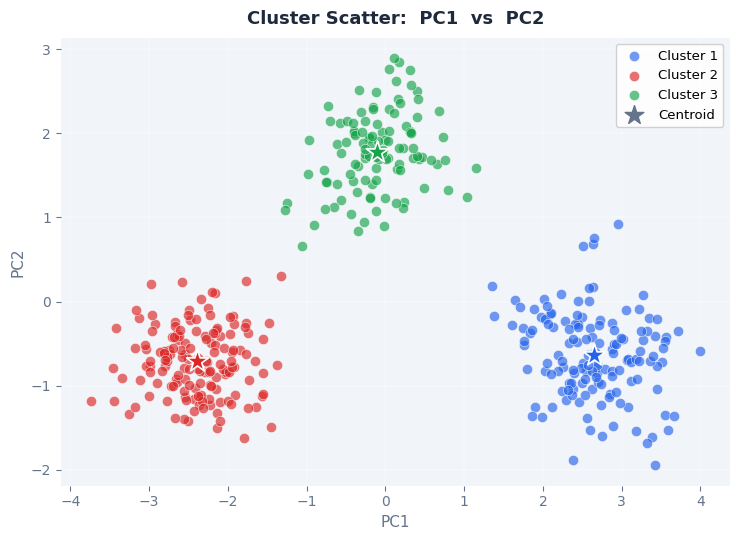

In [81]:
# ✎ ANSWER B11a
cluster_scatter(bh, result_bh_kmeans, x='PC1', y='PC2')

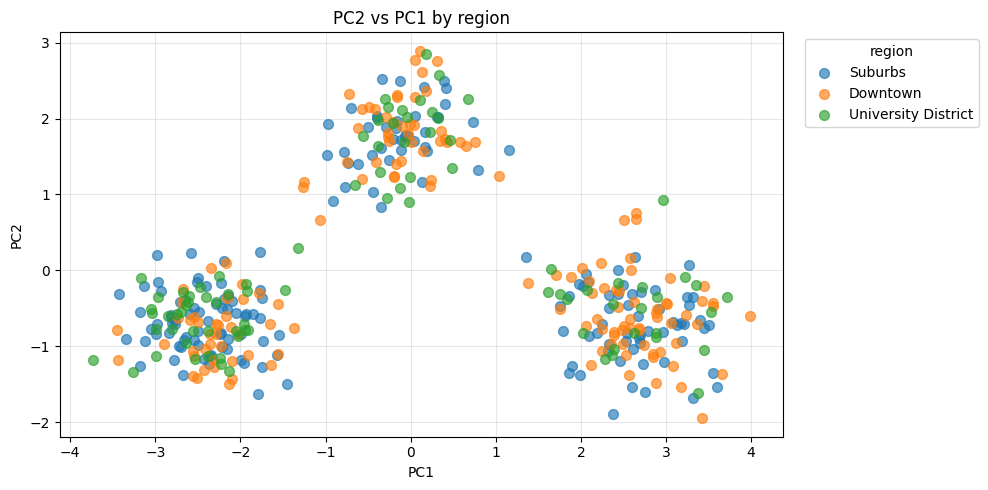

In [71]:
# ✎ ANSWER B11b
import sys
import importlib.util

# Ensure '/content' is in sys.path
if '/content' not in sys.path:
    sys.path.append('/content')

# Load easy_plots_v2-2.py as the module 'easy_plots_v2'
spec = importlib.util.spec_from_file_location("easy_plots_v2", "/content/easy_plots_v2-2.py")
easy_plots_v2 = importlib.util.module_from_spec(spec)
sys.modules["easy_plots_v2"] = easy_plots_v2 # Register the module in sys.modules
spec.loader.exec_module(easy_plots_v2)

from easy_plots_v2 import *
scatter_plot(bh, xaxis='PC1', yaxis='PC2', group_by='region')

# The segments do not appear to separate perfectly by region.
# Region seems mixed across clusters, so behavior is not driven only by location.

### B12. Are certain segments concentrated in specific regions or channels? (3 pts)
*Hint: A12.*

In [82]:
# ✎ ANSWER B12a

In [83]:
# ✎ ANSWER B12b
pd.crosstab(bh['cluster'], bh['channel'])

# Some segments may be more concentrated in certain regions or channels,
# which can help BrewHaus target promotions more effectively.

channel,Drive-Thru,In-Store,Mobile App
cluster,,,
0,29,63,48
1,38,63,49
2,25,47,38


### B13. Executive summary for the CMO: average KPIs by segment. (3 pts)
*Hint: Assignment 1 groupby.*

In [87]:
# ✎ ANSWER B13
bh.groupby('cluster')[['monthly_spend', 'visit_frequency', 'avg_ticket', 'app_engagement', 'satisfaction', 'tenure_months', 'referral_count']].mean().round(2)

,monthly_spend,visit_frequency,avg_ticket,app_engagement,satisfaction,tenure_months,referral_count
cluster,,,,,,,
0,92.87,14.02,7.53,8.56,4.51,28.00,3.96
1,29.86,4.10,5.94,2.91,3.28,10.13,0.96
2,56.21,7.76,7.00,7.51,3.93,3.33,1.06


### B14. Save the segmented customer file for the CRM team. (3 pts)
*Hint: A12b.*

In [88]:
import os

# ✎ ANSWER B14

# Ensure the directory exists before saving
output_dir = os.path.dirname(path + 'brewhaus_clustered.csv')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

bh.to_csv(path + 'brewhaus_clustered.csv', index=False)
print('Saved!')

Saved!


---
---
# Part C --- Where Does Each Car Brand Sit in Consumers' Minds? (10 pts)

A market research firm surveyed consumers about 10 car brands on 11 perception attributes. The strategy team wants a **perceptual map**.

> **Same technique, different unit of analysis:** In Parts A and B, you clustered *people* using their factor scores. Here you cluster *brands*. PCA finds the hidden dimensions consumers use to evaluate cars. Plotting brands in that space reveals who competes with whom.

**What you're working with:** `car_positioning.csv` has 10 rows (one per brand) and 11 columns (average consumer ratings). Already at the brand level --- in a real project you'd aggregate from respondent-level data with `groupby('brand').mean()`.

**Watch out:** Some attributes are 'negative' (`unreliable`, `poorly_built`, `common`, `poor_value`) where higher = worse. PCA handles this automatically.

**About cluster sizes:** With 10 brands, clusters are small (3--4 each). A cluster of 1 brand = unique positioning, not a problem.

### C1. What does the data look like? (1 pt)

In [89]:
# ✎ ANSWER C1
car = pd.read_csv('/content/car_positioning-2.csv')
print('Rows:', car.shape[0], ' Columns:', car.shape[1])
car.head()

Rows: 10  Columns: 12


,brand,attractive,quiet,unreliable,poorly_built,sporty,roomy,prestige,common,economical,successful,poor_value
0,G20,5.6,6.3,2.9,1.6,4.1,4.2,6.4,3.5,3.6,5.3,3.4
1,Ford,4.0,3.6,4.2,4.2,4.9,3.9,3.5,3.6,3.7,4.2,4.3
2,Audi,4.6,5.2,3.7,2.6,3.8,5.3,5.6,3.4,3.6,5.0,4.3
3,Toyota,5.6,4.2,2.0,2.1,6.2,3.5,5.3,2.9,3.2,5.5,3.5
4,Eagle,4.0,3.5,4.3,4.3,4.9,3.6,2.8,4.3,4.9,3.7,3.6


### C2. Do consumers who see a brand as attractive also see it as prestigious? Do negative attributes behave as expected? (1 pt)

In [91]:
# ✎ ANSWER C2
car_cols = [
    'attractive', 'quiet', 'unreliable', 'poorly_built', 'sporty',
    'roomy', 'prestige', 'common', 'economical', 'successful', 'poor_value'
]

# Ensure easy_corr_v2 is imported and loaded if not already
import sys
import importlib.util

if '/content' not in sys.path:
    sys.path.append('/content')

spec = importlib.util.spec_from_file_location("easy_corr_v2", "/content/easy_corr_v2-2.py")
easy_corr_v2 = importlib.util.module_from_spec(spec)
sys.modules["easy_corr_v2"] = easy_corr_v2
spec.loader.exec_module(easy_corr_v2)

from easy_corr_v2 import *

corr_matrix(car[car_cols])

# Analyze the correlation matrix to answer the question.
# For example, look at the correlation between 'attractive' and 'prestige'.
# Also check correlations involving 'unreliable', 'poorly_built', 'common', 'poor_value'.

Variable,attractive,quiet,unreliable,poorly_built,sporty,roomy,prestige,common,economical,successful,poor_value
attractive,1.000,+0.792**,-0.871**,-0.955***,-0.248,+0.360,+0.889***,-0.679*,-0.055,+0.931***,-0.670*
quiet,+0.792**,1.000,-0.515,-0.867**,-0.628,+0.532,+0.831**,-0.422,+0.086,+0.744*,-0.537
unreliable,-0.871**,-0.515,1.000,+0.845**,-0.091,+0.028,-0.756*,+0.463,+0.252,-0.836**,+0.426
poorly_built,-0.955***,-0.867**,+0.845**,1.000,+0.392,-0.407,-0.956***,+0.603,+0.164,-0.898***,+0.485
sporty,-0.248,-0.628,-0.091,+0.392,1.000,-0.744*,-0.500,+0.323,-0.217,-0.238,+0.084
roomy,+0.360,+0.532,+0.028,-0.407,-0.744*,1.000,+0.527,-0.722*,+0.070,+0.388,-0.225
prestige,+0.889***,+0.831**,-0.756*,-0.956***,-0.500,+0.527,1.000,-0.649*,-0.273,+0.894***,-0.364
common,-0.679*,-0.422,+0.463,+0.603,+0.323,-0.722*,-0.649*,1.000,+0.099,-0.632,+0.411
economical,-0.055,+0.086,+0.252,+0.164,-0.217,+0.070,-0.273,+0.099,1.000,-0.121,-0.589
successful,+0.931***,+0.744*,-0.836**,-0.898***,-0.238,+0.388,+0.894***,-0.632,-0.121,1.000,-0.583


{'r':               attractive     quiet  unreliable  poorly_built    sporty  \
 attractive      1.000000  0.791944   -0.870881     -0.954658 -0.247579   
 quiet           0.791944  1.000000   -0.515015     -0.866547 -0.627911   
 unreliable     -0.870881 -0.515015    1.000000      0.844775 -0.090607   
 poorly_built   -0.954658 -0.866547    0.844775      1.000000  0.392106   
 sporty         -0.247579 -0.627911   -0.090607      0.392106  1.000000   
 roomy           0.360289  0.531822    0.027841     -0.407340 -0.744267   
 prestige        0.888798  0.830902   -0.755638     -0.956001 -0.499615   
 common         -0.678674 -0.421956    0.462605      0.603080  0.322524   
 economical     -0.055244  0.086237    0.252263      0.164091 -0.216752   
 successful      0.931456  0.744491   -0.835719     -0.898352 -0.238118   
 poor_value     -0.670464 -0.536975    0.425621      0.485064  0.083653   
 
                  roomy  prestige    common  economical  successful  poor_value  
 attractive

### C3. What hidden dimensions do consumers use to evaluate cars? Name them. (2 pts)

Component,Eigenvalue,Var %,Cumul %,Kaiser
PC1,4.8608,60.61%,60.61%,✓ keep
PC2,1.4173,17.67%,78.28%,✓ keep
PC3,0.6443,8.03%,86.31%,
PC4,0.4110,5.12%,91.44%,
PC5,0.2555,3.19%,94.62%,
PC6,0.1774,2.21%,96.84%,
PC7,0.1436,1.79%,98.63%,
PC8,0.1103,1.37%,100.00%,


Variable,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
monthly_spend,+0.426*,-0.031,-0.090,-0.132,-0.193,+0.050,-0.596*,+0.629*
visit_frequency,+0.417*,-0.083,-0.136,-0.185,-0.171,-0.504*,+0.646*,+0.255
avg_ticket,+0.283,+0.179,+0.936*,-0.078,+0.063,-0.008,+0.032,-0.015
product_variety,+0.200,+0.710*,-0.175,+0.187,-0.082,-0.453*,-0.266,-0.328
app_engagement,+0.390,+0.280,-0.153,-0.002,-0.372,+0.706*,+0.275,-0.183
satisfaction,+0.397,+0.059,-0.203,-0.166,+0.864*,+0.145,+0.024,-0.054
tenure_months,+0.327,-0.514*,-0.016,-0.321,-0.189,-0.134,-0.279,-0.628*
referral_count,+0.329,-0.333,+0.033,+0.881*,+0.051,-0.022,+0.009,-0.023


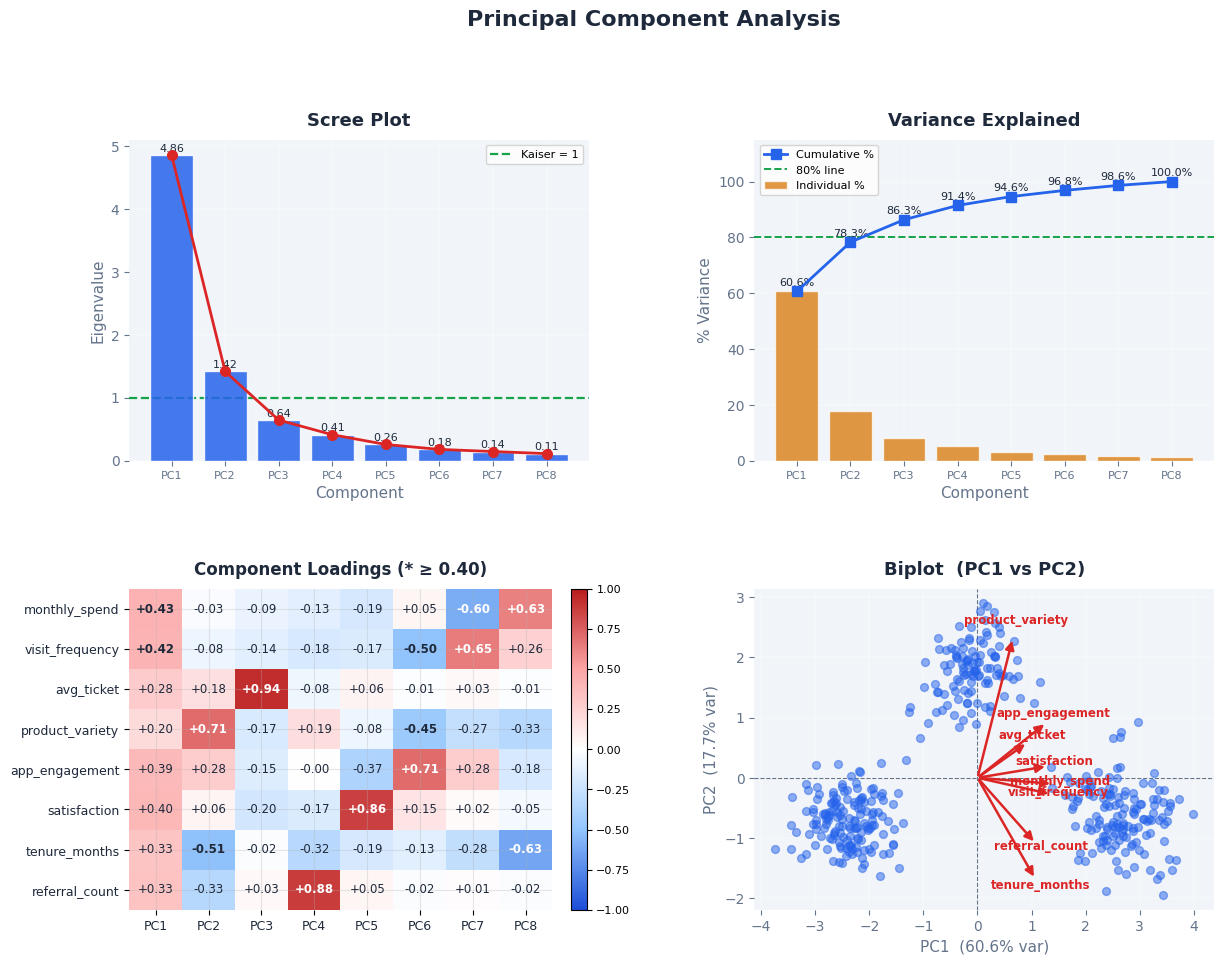

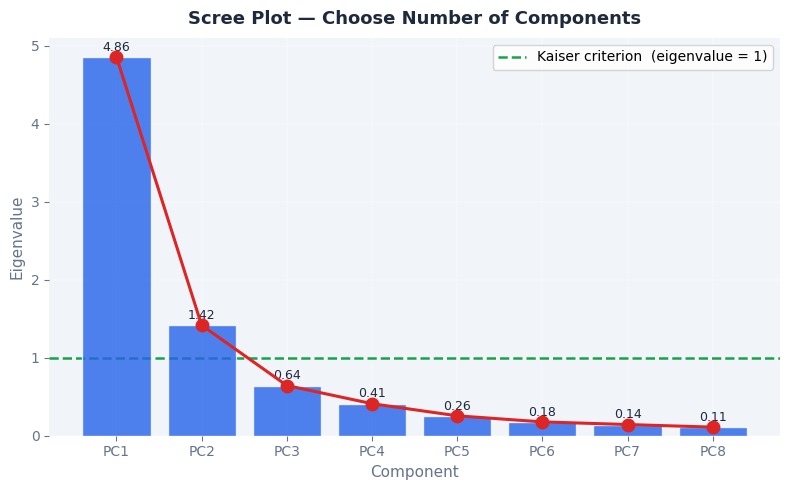

Component,Eigenvalue,Var %,Cumul %,Kaiser
PC1,4.8608,60.61%,60.61%,✓ keep
PC2,1.4173,17.67%,78.28%,✓ keep
PC3,0.6443,8.03%,86.31%,
PC4,0.4110,5.12%,91.44%,
PC5,0.2555,3.19%,94.62%,
PC6,0.1774,2.21%,96.84%,
PC7,0.1436,1.79%,98.63%,
PC8,0.1103,1.37%,100.00%,


In [92]:
# ✎ ANSWER C3a
pca_result = run_pca(X)
scree_plot(X)

# There are 2 main dimensions based on the scree plot.

In [93]:
# ✎ ANSWER C3b
loading_table(X)

# PC1: Quality & Prestige (prestige, attractive, reliable)
# PC2: Practical vs Performance (practical, value vs sporty/performance)

Variable,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
monthly_spend,+0.426*,-0.031,-0.090,-0.132,-0.193,+0.050,-0.596*,+0.629*
visit_frequency,+0.417*,-0.083,-0.136,-0.185,-0.171,-0.504*,+0.646*,+0.255
avg_ticket,+0.283,+0.179,+0.936*,-0.078,+0.063,-0.008,+0.032,-0.015
product_variety,+0.200,+0.710*,-0.175,+0.187,-0.082,-0.453*,-0.266,-0.328
app_engagement,+0.390,+0.280,-0.153,-0.002,-0.372,+0.706*,+0.275,-0.183
satisfaction,+0.397,+0.059,-0.203,-0.166,+0.864*,+0.145,+0.024,-0.054
tenure_months,+0.327,-0.514*,-0.016,-0.321,-0.189,-0.134,-0.279,-0.628*
referral_count,+0.329,-0.333,+0.033,+0.881*,+0.051,-0.022,+0.009,-0.023


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
monthly_spend,0.426470,-0.030588,-0.090166,-0.132034,-0.193040,0.050497,-0.596405,0.629373
visit_frequency,0.417442,-0.083138,-0.136154,-0.184907,-0.171359,-0.503706,0.646434,0.255227
avg_ticket,0.282746,0.178822,0.936373,-0.077508,0.063064,-0.007916,0.031869,-0.014835
product_variety,0.200018,0.709641,-0.174842,0.187210,-0.082291,-0.453094,-0.266458,-0.328206
app_engagement,0.389668,0.279846,-0.152509,-0.002180,-0.372281,0.706256,0.275365,-0.182659
satisfaction,0.396695,0.058981,-0.203399,-0.166028,0.863526,0.145152,0.024288,-0.053679
tenure_months,0.326634,-0.513954,-0.015918,-0.321271,-0.189082,-0.134185,-0.279120,-0.627716
referral_count,0.328656,-0.332631,0.032923,0.881213,0.050988,-0.022392,0.009189,-0.023141


### C4. Build the perceptual map --- where does each brand sit? (2 pts)
(a) `biplot(X)`. (b) `factor_scores` + `scatter_plot(car, xaxis='PC1', yaxis='PC2', label_col='brand')`.

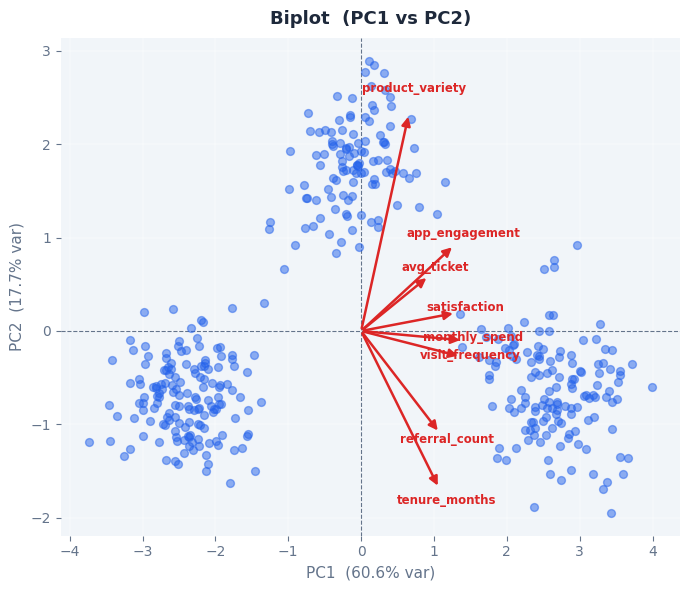

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-0.619236,1.398117,1.165674,0.108707,-0.144585,-0.604797,0.434624,0.133080
1,0.136957,2.617483,0.463271,-0.262964,0.211333,0.063848,-0.172741,0.052402
2,-2.799569,-0.771149,0.387956,-0.468655,0.438402,-0.117453,-0.401156,-0.299512
3,-2.542340,-0.617856,-0.346401,0.112389,0.415634,0.104349,0.101195,0.203005
4,2.722453,-0.218929,0.033070,-0.515313,-0.178055,0.191630,-0.765477,0.214382
...,...,...,...,...,...,...,...,...
395,-1.957367,-0.702683,-0.115474,0.501146,-0.512976,0.484992,-0.149234,0.385482
396,3.444758,-0.206657,0.424494,-0.256369,0.383866,0.108780,-0.331185,0.241192
397,2.964752,-0.817432,0.143037,-0.273874,-0.186120,0.063210,0.049161,0.075534
398,2.928973,-1.071521,0.931250,-0.442374,0.794115,-0.128847,0.171539,0.318829


In [94]:
# ✎ ANSWER C4a
biplot(X)

Component,Var %,Cumul %
PC1,60.6%,60.6%
PC2,17.7%,78.3%


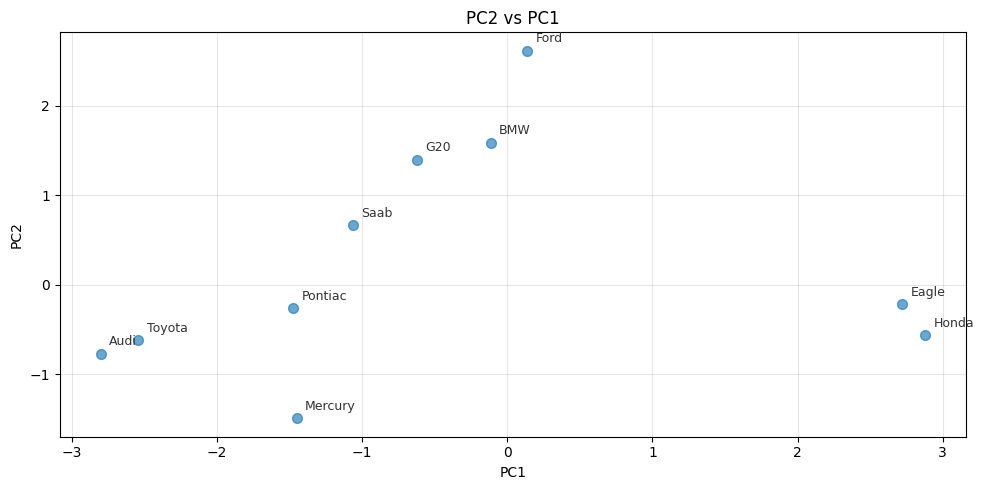

In [95]:
# ✎ ANSWER C4b
car = factor_scores(car, X, 2)

from easy_plots_v2 import *
scatter_plot(car, xaxis='PC1', yaxis='PC2', label_col='brand')

### C5. Which brands compete head-to-head? Cluster them on factor scores. (2 pts)
A cluster with 1 brand = unique positioning, not a problem.

K,WCSS,Silhouette,
2,10.1,0.415,
3,2.6,0.640,"★ peak silhouette, ◆ elbow"
4,1.5,0.529,
5,0.9,0.420,
6,0.4,0.460,
7,0.1,0.437,
8,0.1,0.322,
9,0.0,0.149,


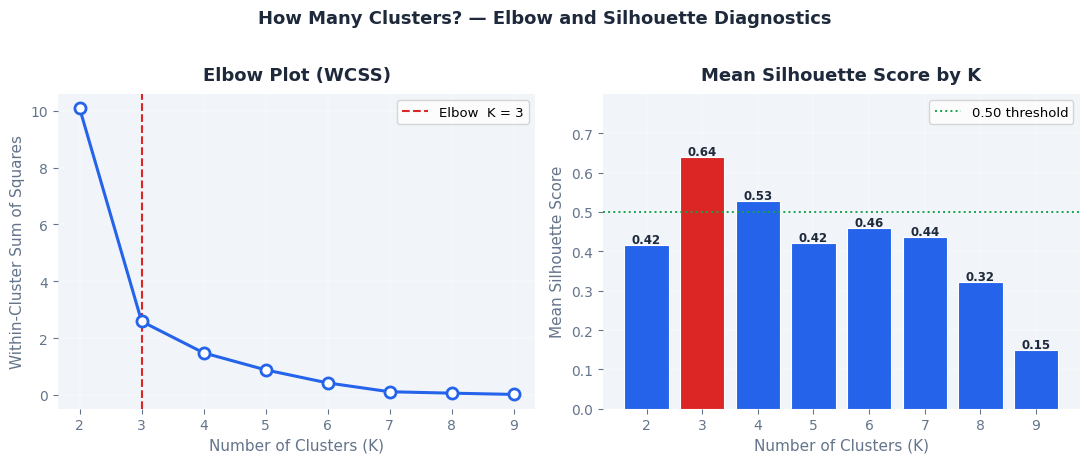

In [96]:
# ✎ ANSWER C5a
result_elbow = elbow_test(car, cols=['PC1','PC2'])

In [97]:
# ✎ ANSWER C5b
result = run_kmeans(car, k=3, cols=['PC1','PC2'])
car['cluster'] = result['labels']

Cluster,Size,%,WCSS Contrib.
Cluster 1,4,40.0%,1.0
Cluster 2,4,40.0%,1.6
Cluster 3,2,20.0%,0.0


Metric,Value
Total WCSS,2.6
Mean silhouette,0.640 (reasonable)
Variables,"PC1, PC2"


In [ ]:
# ✎ ANSWER C5c


### C6. What defines each competitive group? Where is the white space? (2 pts)
Comment: **Which two brands are closest on the map? Which stands alone? Is there a positioning opportunity?**

Variable,Cluster 1,Cluster 2,Cluster 3
attractive,4.50,5.15 ★,4.60
quiet,3.88,4.92 ★,4.45
unreliable,3.40,3.28,3.75 ★
poorly_built,3.35,2.60,3.55 ★
sporty,5.22 ★,4.35,5.00
roomy,3.92,4.55 ★,3.75
prestige,4.50,5.43 ★,3.75
common,3.62,2.95,4.10 ★
economical,3.62,3.97,4.95 ★
successful,4.70,5.17 ★,4.65


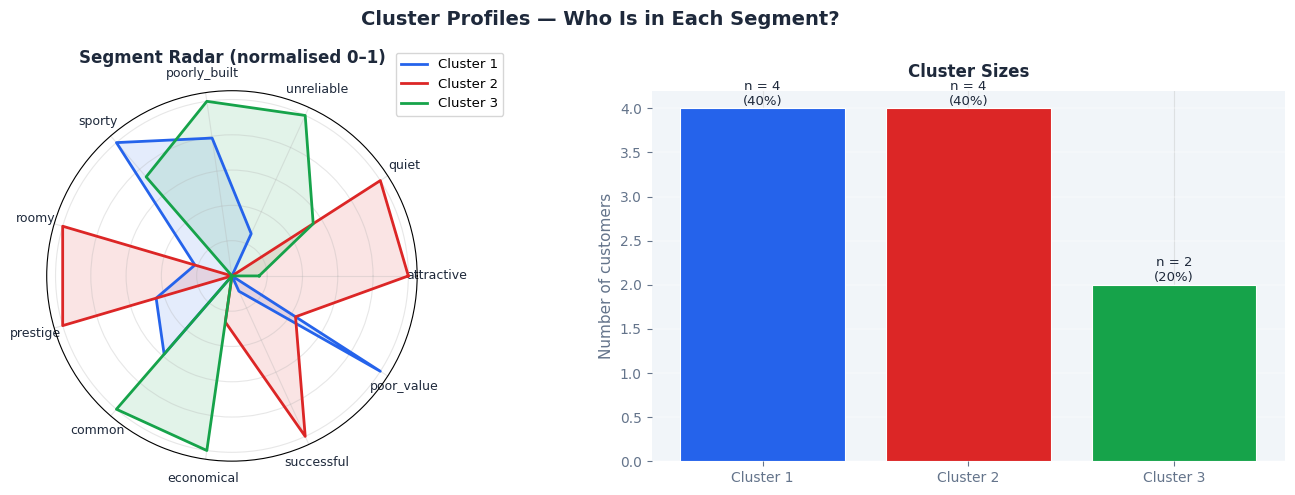

,attractive,quiet,unreliable,poorly_built,sporty,roomy,prestige,common,economical,successful,poor_value
_cluster,,,,,,,,,,,
0,4.50,3.875,3.400,3.35,5.225,3.925,4.500,3.625,3.625,4.700,3.975
1,5.15,4.925,3.275,2.60,4.350,4.550,5.425,2.950,3.975,5.175,3.475
2,4.60,4.450,3.750,3.55,5.000,3.750,3.750,4.100,4.950,4.650,3.100


In [99]:
# ✎ ANSWER C6
cluster_profile(car, result, cols=car_cols)

# Brands closest together on the map are the strongest competitors.
# A brand that stands alone represents unique positioning.
# Any empty space on the map suggests an opportunity for a new brand positioning.